<a href="https://colab.research.google.com/github/PriyanshuJVM/7th-sem-final-project/blob/main/Brain_Tumor_3000_working_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor Detection Project
This project implements an end-to-end pipeline for detecting brain tumors from MRI scans using a Convolutional Neural Network (CNN).

In [2]:
import os
import cv2
import imutils
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# 1. Download and Extract Dataset
!wget --no-check-certificate 'https://github.com/SartajBhuvaji/Brain-Tumor-Classification-DataSet/archive/refs/heads/master.zip' -O brain_dataset.zip

with zipfile.ZipFile('brain_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('data_raw')

# Define paths - Including ALL tumor types for a robust 'Yes' class
base_dir = 'data_raw/Brain-Tumor-Classification-DataSet-master/Training'
tumor_types = ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']
no_tumor_dir = os.path.join(base_dir, 'no_tumor')

print("Data paths verified.")

--2026-05-20 09:38:52--  https://github.com/SartajBhuvaji/Brain-Tumor-Classification-DataSet/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/SartajBhuvaji/Brain-Tumor-Classification-DataSet/zip/refs/heads/master [following]
--2026-05-20 09:38:53--  https://codeload.github.com/SartajBhuvaji/Brain-Tumor-Classification-DataSet/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.112.10
Connecting to codeload.github.com (codeload.github.com)|140.82.112.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘brain_dataset.zip’

brain_dataset.zip       [               <=>  ]  86.97M  30.7MB/s    in 2.8s    

2026-05-20 09:38:56 (30.7 MB/s) - ‘brain_dataset.zip’ saved [91198591]

Data paths verified.


In [3]:
def crop_brain_contour(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    if not cnts: return image
    c = max(cnts, key=cv2.contourArea)
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])
    return image[extTop[1]:extBot[1], extLeft[0]:extRight[0]].copy()

def load_data(size=(224, 224)):
    X, y = [], []
    # Load all tumor images
    for t_type in tumor_types:
        path = os.path.join(base_dir, t_type)
        for filename in os.listdir(path):
            img = cv2.imread(os.path.join(path, filename))
            if img is not None:
                img = crop_brain_contour(img)
                img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
                X.append(img / 255.0)
                y.append(1) # Tumor

    # Load no_tumor images
    for filename in os.listdir(no_tumor_dir):
        img = cv2.imread(os.path.join(no_tumor_dir, filename))
        if img is not None:
            img = crop_brain_contour(img)
            img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
            X.append(img / 255.0)
            y.append(0) # No Tumor

    return np.array(X), np.array(y)

print("Preprocessing images (including all tumor types)... highlights potential coverage issues.")
X, y = load_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
print(f"Total images: {len(X)}. Training: {len(X_train)}, Testing: {len(X_test)}")

Preprocessing images (including all tumor types)... highlights potential coverage issues.
Total images: 2870. Training: 2439, Testing: 431


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation to improve generalization
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Build a slightly deeper CNN for better feature extraction
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training model with Data Augmentation...")
# Fit with augmentation
batch_size = 32
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    epochs=15,
    validation_data=(X_test, y_test)
)

loss, acc = model.evaluate(X_test, y_test)
print(f"Final Accuracy after Augmentation: {acc*100:.2f}%")

Training model with Data Augmentation...
Epoch 1/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 304s 4s/step - accuracy: 0.8637 - loss: 0.4593 - val_accuracy: 0.8701 - val_loss: 0.2473
Epoch 2/15
 1/76 ━━━━━━━━━━━━━━━━━━━━ 4:02 3s/step - accuracy: 0.9062 - loss: 0.3657

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 273ms/step - accuracy: 0.9062 - loss: 0.3657 - val_accuracy: 0.8724 - val_loss: 0.2518
Epoch 3/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 279s 4s/step - accuracy: 0.8866 - loss: 0.2685 - val_accuracy: 0.9095 - val_loss: 0.2002
Epoch 4/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 273ms/step - accuracy: 0.9062 - loss: 0.2051 - val_accuracy: 0.9049 - val_loss: 0.1952
Epoch 5/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 304s 4s/step - accuracy: 0.9123 - loss: 0.2139 - val_accuracy: 0.9281 - val_loss: 0.1648
Epoch 6/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 25s 274ms/step - accuracy: 0.9688 - loss: 0.0817 - val_accuracy: 0.9258 - val_loss: 0.1668
Epoch 7/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 298s 4s/step - accuracy: 0.9169 - loss: 0.2076 - val_accuracy: 0.9374 - val_loss: 0.1519
Epoch 8/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 273ms/step - accuracy: 0.9062 - loss: 0.1426 - val_accuracy: 0.9397 - val_loss: 0.1517
Epoch 9/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 291s 4s/step - accuracy: 0.9182 - loss: 0.1881 - val_accuracy: 0.9466 - val_

14/14 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step


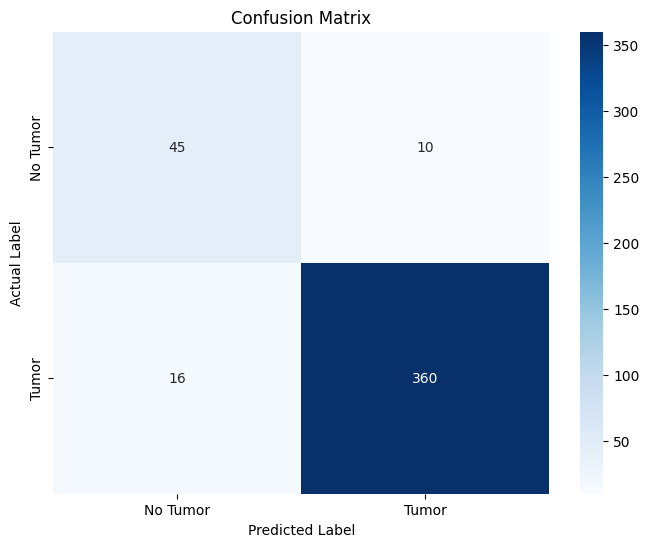


Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.74      0.82      0.78        55
       Tumor       0.97      0.96      0.97       376

    accuracy                           0.94       431
   macro avg       0.86      0.89      0.87       431
weighted avg       0.94      0.94      0.94       431



In [5]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Print Detailed Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Tumor', 'Tumor']))

### Test the Model on a New Image
Run the cell below to upload an MRI scan and see the model's prediction.

Saving Te-no_102sfsdgsdg.jpg to Te-no_102sfsdgsdg.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


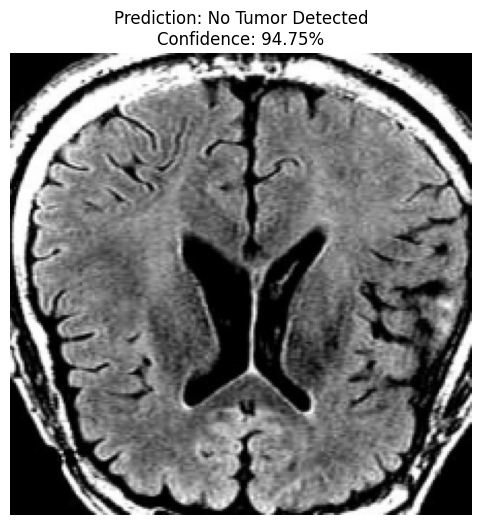

In [10]:
from google.colab import files
import io
from PIL import Image

def predict_uploaded_image():
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Load image
        img = cv2.imdecode(np.frombuffer(uploaded[filename], np.uint8), cv2.IMREAD_COLOR)

        # Preprocess using the same logic as training
        cropped = crop_brain_contour(img)
        resized = cv2.resize(cropped, (224, 224), interpolation=cv2.INTER_AREA)
        normalized = resized / 255.0
        input_tensor = np.expand_dims(normalized, axis=0)

        # Predict
        prediction = model.predict(input_tensor)[0][0]
        label = "Tumor Detected" if prediction > 0.5 else "No Tumor Detected"
        confidence = prediction if prediction > 0.5 else 1 - prediction

        # Display Result
        plt.figure(figsize=(6, 6))
        plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
        plt.title(f"Prediction: {label}\nConfidence: {confidence*100:.2f}%")
        plt.axis('off')
        plt.show()

predict_uploaded_image()

### Preprocessing Diagnostic
If you are getting incorrect results, run this cell to see how the model 'sees' your image after cropping and resizing.

Saving Te-pi_102.jpg to Te-pi_102 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


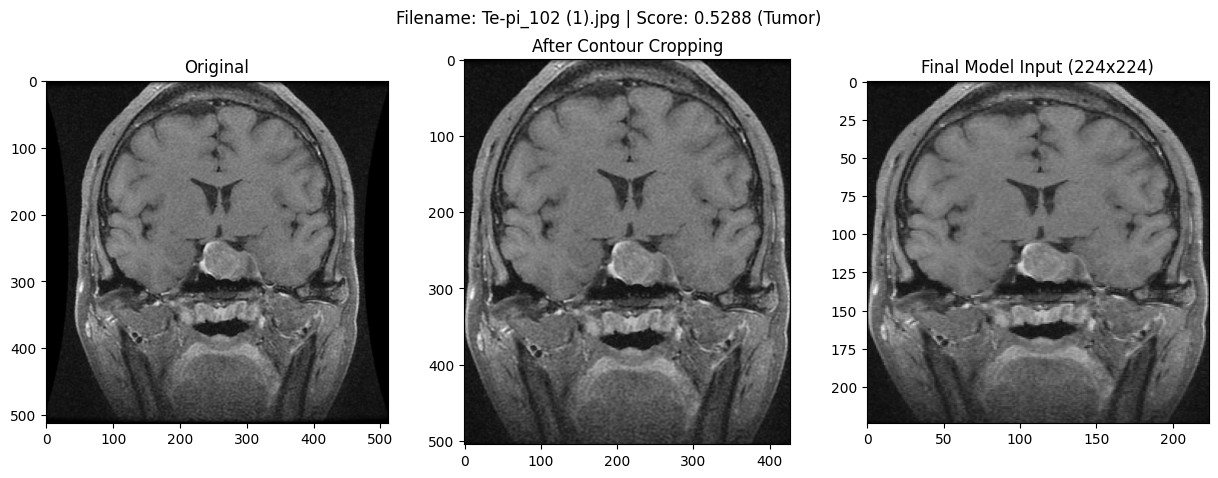

In [7]:
def diagnostic_predict():
    uploaded = files.upload()
    for filename in uploaded.keys():
        img = cv2.imdecode(np.frombuffer(uploaded[filename], np.uint8), cv2.IMREAD_COLOR)

        # Step-by-step visualization
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        cropped = crop_brain_contour(img)
        resized = cv2.resize(cropped, (224, 224))

        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax[0].set_title("Original")

        ax[1].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
        ax[1].set_title("After Contour Cropping")

        ax[2].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
        ax[2].set_title("Final Model Input (224x224)")

        # Prediction
        normalized = resized / 255.0
        pred = model.predict(np.expand_dims(normalized, axis=0))[0][0]

        plt.suptitle(f"Filename: {filename} | Score: {pred:.4f} ({'Tumor' if pred > 0.5 else 'No Tumor'})")
        plt.show()

diagnostic_predict()